# Exercises and Self Study on Link Prediction with Shallow Embeddings

## Theoretical Background for Link Prediction with Shallow Embeddings

### Core Concepts

**Link Prediction**: The task of predicting missing or future edges in a graph. Given a partially observed network, we aim to identify node pairs that are likely to be connected.

**Graph Embeddings**: A representation of graph nodes in a lower-dimensional vector space, where geometric proximity reflects structural similarity in the original graph.

**Shallow Embeddings**: Simple, computationally efficient embeddings that map nodes to points in a low-dimensional space (typically 2D or small k-dimensional). Unlike deep learning approaches, they use classical methods to generate representations.

### Layout Algorithms as Embeddings

This exercise uses graph layout algorithms (Spring Layout, Circular Layout, Kamada-Kawai) to create embeddings:
- **Spring Layout**: Uses physics-inspired forces (springs between connected nodes) to position nodes. Connected nodes are drawn closer; nodes with many common neighbors are attracted.
- **Circular Layout**: Arranges nodes in a circle, less influenced by graph structure.
- **Kamada-Kawai Layout**: Uses graph-theoretic distances to determine positions; more structure-preserving than circular but computationally heavier.

### Similarity Measures

**Dot Product Similarity**: $\text{sim}(u, v) = \mathbf{X}_u \cdot \mathbf{X}_v = \sum_i X_{u,i} \times X_{v,i}$

This measures the geometric similarity of embedding vectors. Nodes closer together in embedding space have higher dot product similarity.

Geometric interpretation:

- High dot product: Nodes are positioned close together / in similar directions from origin → likely connected

- Low dot product: Nodes are far apart / opposite directions → unlikely to be connected

- Link prediction intuition: If two nodes have similar embeddings (high dot product), they're more likely to form a link

### Link Prediction Evaluation Metrics

**Hit Rate@K**: Proportion of sampled (hidden) edges where the true target node appears in the top-K ranked nodes by similarity score.

$$\text{HitRate@K} = \frac{\text{Number of hits within top-K}}{|\text{Test edges}|}$$

**Mean Reciprocal Rank (MRR)**: Average of the reciprocal ranks of true target nodes.

$$\text{MRR} = \frac{1}{|E|} \sum_{(u,v) \in E} \frac{1}{\text{rank}(v \text{ for } u)}$$

### Key Methods to Explore

1. **Position-Based Embeddings** (current approach): Use layout algorithm coordinates directly as embeddings.

2. **SVD (Singular Value Decomposition)**: Factorizes the adjacency matrix $A = U \Sigma V^T$. Top singular vectors provide low-rank approximation capturing graph structure. Theoretical: preserves matrix spectral properties, good for capturing global graph structure.

3. **Node2Vec**: A random walk-based method that balances depth-first and breadth-first exploration. Creates sequences of nodes via random walks, then uses skip-gram (like Word2Vec) to learn embeddings. Captures both local neighborhoods and global graph structure.

### Experimental Variations

- **Layout algorithms**: Different layouts preserve different structural properties
- **Dimensionality**: How many dimensions in embedding space?
- **Evaluation criteria**: Should you normalize by number of edges or total nodes?
- **Graph properties**: Different embedding methods may work better on different graph types (sparse vs. dense, small-world vs. power-law, etc.)

### Workflow for This Exercise

1. Start with position-based embeddings from layout algorithms
2. Remove edges (create test set)
3. Recalculate layout on modified graph to create new embeddings
4. Score remaining edges by similarity of embeddings
5. Evaluate with Hit Rate@K
6. Repeat with SVD and Node2Vec embeddings
7. Compare performance and reflect on why methods succeed/fail on this dataset

### Please note, that it matters where you rerun. To be sure, you run all the commands from the start after you have changed some constants

In the following code we will use the idea of simple mapping/transformation from graph to a space of two coordinates given by the layout drawing algorithm. It is simple, not theoretically grounded excercixe just to see how simple embeddings (into a space of two coordinates) affect the link prediction. The idea is simple: the nodes which are connected or supposed to be connected are usually drawn closer to each other and those with many links in common will be drawn even closer, espacially when we have a club bellonging information and we use the spring layout.

In [109]:
import networkx as ntx # networkX library for working with graphs
import numpy as np #numpy with some math and linear algebra
import pandas as pd #data frames for working with tabular data
import scipy # library for scientific computing
import random # library for randomly sampling from data
import math # math functions such as sqrt
import torch # machine learning library - pytorch
import torch_geometric.nn as torchg # libraries with some models for pytorch for example Node2Vec

In [110]:
random.seed(3407)

In [111]:
zachary = ntx.karate_club_graph() #importing karate club network

print("Number of nodes: " + str(zachary.number_of_nodes()) + ", Number of edges: " + str(zachary.number_of_edges()) + ".")

# sampling
sampled_edges = random.sample(list(zachary.edges), round(0.2*zachary.number_of_edges()))
print(sampled_edges)

Number of nodes: 34, Number of edges: 78.
[(0, 8), (20, 32), (1, 2), (8, 32), (2, 9), (18, 33), (5, 16), (13, 33), (2, 32), (23, 32), (25, 31), (19, 33), (3, 12), (3, 13), (2, 13), (0, 7)]


Here we are splitting the nodes into two classes (belonging to a specific club) which affect the coordinates of drawing layouts and hence also embeddings. You can experiment with this. There is also just a homogenious graph set up - the commented line. You may also use multiple classes and multiple attributes but you will need to add that data to the graph, because in current form it only has club belonging as a node attribute.

In [112]:
Y=np.array(list(1.0  if zachary.nodes[n]["club"]=="Officer" else 0.0 for n in zachary.nodes()))
#Y= np.array(list(0.0 for n in zachary.nodes()))

Here you have three different layouts, each likely drawing the graph into a different layout influencing the tranformations, embeddings, and similarities.

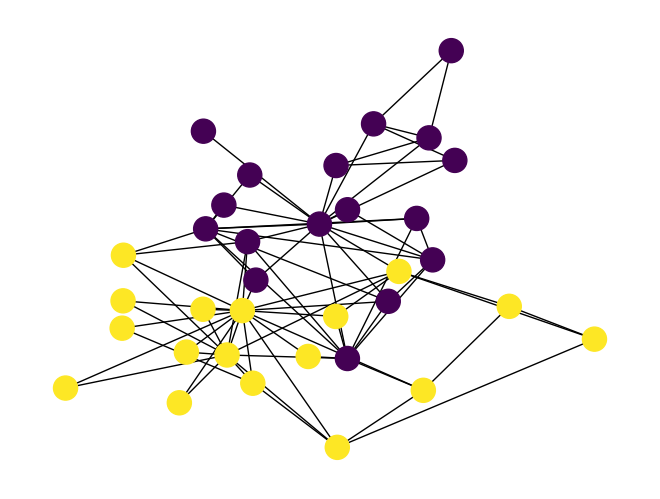

In [113]:
# layout = ntx.circular_layout(zachary)
layout = ntx.kamada_kawai_layout(zachary)
# layout = ntx.spring_layout(zachary)
# with the seed set for reproducibility
# layout = ntx.spring_layout(zachary, seed=0)
ntx.draw(zachary,pos=layout,node_color=Y)

We will make embeddings from the positions in the graph. Please note that the algorithm changes the layout sometimes, so the embeddings and similarities change also. Now the graph is drawn and split on one attribute only. You can play with other attributes to get something else. And please note, that this is not a standard approach. This is just to exemplify some transformation to lowe dimmensional space. It may be it does not work. It will likely work for node classification though. But this is a different task.

In [114]:
X=np.zeros((zachary.order(),2))
for i in range(zachary.order()):
    X[i,:]=layout[i]

In [115]:
print("Embedding vectors: \n",X)

Embedding vectors: 
 [[ 0.04297991  0.22030637]
 [-0.26156599  0.19882926]
 [ 0.11777872 -0.38401862]
 [ 0.34592475  0.05941575]
 [ 0.40530719  0.50663395]
 [ 0.3362071   0.60793562]
 [ 0.18779413  0.67085451]
 [ 0.30323286  0.24575807]
 [-0.14937313  0.14123114]
 [ 0.01287645 -0.37485436]
 [ 0.08740253  0.48354353]
 [-0.2675342   0.63792659]
 [ 0.11818216  0.2847033 ]
 [ 0.22713271 -0.1268925 ]
 [-0.48262243 -0.12478558]
 [-0.63655094 -0.51693011]
 [ 0.39575458  1.        ]
 [-0.21280376  0.30567951]
 [-0.31313309 -0.35520387]
 [-0.12717901 -0.03165838]
 [-0.26868721 -0.16253729]
 [-0.14349971  0.44085903]
 [-0.33197986 -0.58315283]
 [ 0.09074863 -0.78347714]
 [ 0.5509485  -0.14946208]
 [ 0.77898773 -0.29699752]
 [-0.48504343 -0.24770295]
 [ 0.32100817 -0.52707708]
 [ 0.08655889 -0.19488511]
 [-0.13538871 -0.49520116]
 [-0.48160489  0.08027171]
 [ 0.25574457  0.0076252 ]
 [-0.20425968 -0.36820328]
 [-0.16334351 -0.16853369]]


In [116]:
SimEmbPosition = [[0 for _ in range(zachary.order())] for _ in range(zachary.order())]

for i in range(zachary.order()):
    for j in range(zachary.order()):
        SimEmbPosition[i][j] = np.dot(X[i, :], X[j, :])

In [117]:
# print(SimEmbPosition)

We are going to remove the sampled edges from the graph, so let's just save the similarities if those edges are considered in the graph that we can compare them later. I am going to use a different label for the embeddigns variable XN and also for similarity matrix SimEmbPositionXN.

In [118]:
for u, v in sampled_edges:
    print("(" +  str(u) + ", " + str(v) + ", "  + str(SimEmbPosition[u][v]) + ")")

(0, 8, 0.024694077321009023)
(20, 32, 0.11472872829479015)
(1, 2, -0.10716104445749396)
(8, 32, -0.021490859829485103)
(2, 9, 0.1454676256352687)
(18, 33, 0.11101207784682103)
(5, 16, 0.7409911202737368)
(13, 33, -0.015714993462509083)
(2, 32, 0.1173394713661133)
(23, 32, 0.26994256621139046)
(25, 31, 0.1969572176138883)
(19, 33, 0.026109369682042357)
(3, 12, 0.05779799539955973)
(3, 13, 0.07103141472613725)
(2, 13, 0.07548048071062559)
(0, 7, 0.06717498814695223)


In [119]:
# remove those sampled edges
for uN,vN in sampled_edges:
    zachary.remove_edge(uN, vN)

Of course it will likely affect (maybe only a little bit) the drawing and embeddings, so we need to reconstruct the embeddings. Please observe the changes on the similarity

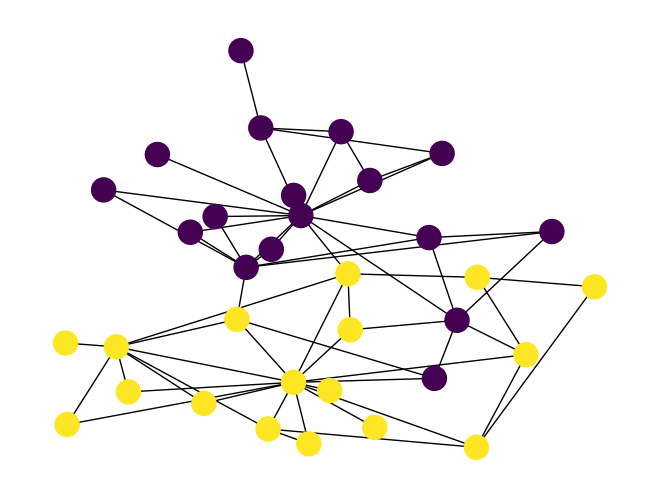

In [120]:
# layoutN = ntx.circular_layout(zachary)
layoutN = ntx.kamada_kawai_layout(zachary)
#layoutN = ntx.spring_layout(zachary)
# with the seed set for reproducibility
# layoutN = ntx.spring_layout(zachary, seed=4)
ntx.draw(zachary,pos=layoutN,node_color=Y)

In [121]:
XN=np.zeros((zachary.order(),2))
for i in range(zachary.order()):
    XN[i,:]=layoutN[i]

In [122]:
print("Embedding vectors: \n",XN)

Embedding vectors: 
 [[-0.01471431  0.30642272]
 [-0.12828298  0.08837186]
 [ 0.30905273 -0.13419724]
 [ 0.25100418  0.21369621]
 [ 0.06866878  0.65916658]
 [ 0.27820163  0.56772862]
 [-0.09779035  0.67485175]
 [ 0.50583982  0.23911801]
 [ 0.26222251 -0.37850623]
 [ 0.13845052 -0.58487742]
 [ 0.1282587   0.45383162]
 [-0.31226989  0.56312191]
 [-0.02974343  0.39103793]
 [-0.42377417  0.41421245]
 [-0.21590111 -0.48393533]
 [-0.49947216 -0.57265736]
 [-0.13897283  1.        ]
 [-0.07599493  0.16436613]
 [-0.50275004 -0.23008104]
 [-0.19246688  0.30212484]
 [ 0.04525816 -0.42993169]
 [-0.24398672  0.23610126]
 [-0.37242805 -0.43550776]
 [ 0.34926153 -0.66872112]
 [ 0.35119949  0.04643167]
 [ 0.59411868  0.00674805]
 [ 0.00182097 -0.65391507]
 [ 0.45206451 -0.27873461]
 [ 0.0876638  -0.1743492 ]
 [-0.08257124 -0.59158335]
 [-0.14731757 -0.13027416]
 [ 0.08280545  0.06122433]
 [-0.3973953  -0.24601714]
 [-0.03005952 -0.39526717]]


In [123]:
SimEmbPositionXN = [[0 for _ in range(zachary.order())] for _ in range(zachary.order())]

In [124]:
for i in range(zachary.order()):
    for j in range(zachary.order()):
        # MIGHT BE AN ERROR WAS np.dot(XN[i, :], X[j, :])
        SimEmbPositionXN[i][j] = np.dot(XN[i, :], XN[j, :])

In [125]:
for u, v in sampled_edges:
    print("(" +  str(u) + ", " + str(v) + ", "  + str(SimEmbPositionXN[u][v]) + ")")

(0, 8, -0.119841329213063)
(20, 32, 0.08778518554596515)
(1, 2, -0.05150546477780711)
(8, 32, -0.011086969353820877)
(2, 9, 0.12127745034334543)
(18, 33, 0.10605590460039942)
(5, 16, 0.5290661487802686)
(13, 33, -0.15098613661213833)
(2, 32, -0.08980128088935771)
(23, 32, 0.02572196949778427)
(25, 31, 0.04960940798556311)
(19, 33, -0.11363457138340699)
(3, 12, 0.07609759889034201)
(3, 13, -0.01785345819664265)
(2, 13, -0.18655473436909992)
(0, 7, 0.06582810819594379)


You can see that the similarities got smaller. Which could also mean that maybe this kind of transformation is not the best one for link predictions.

We can also try to run the test experiment on this in the simlar sense as in the last self study and excercise and accumulate the hit rate or MRR.

In [126]:
k = 10 # the size of the list to consider
countHits = 0 # counter for hits
mrr_layout = 0

In [127]:
for u, v in sampled_edges:
    LinkPredictionList = SimEmbPositionXN[u] # extracting list of similar nodes for current node
    sort_index = np.argsort(LinkPredictionList) # sorting according to the similarity value
    position_in_the_list = list(sort_index).index(v) # finding position of the hidden node (the one where the edge was removed and was supposed to be)

    rank = position_in_the_list + 1  # ranks start at 1, not 0
    mrr_layout += 1 / rank  # add reciprocal rank

    if(position_in_the_list < k): countHits = countHits + 1 # adding to the counter if in the position which is within top K

Please see the difference between the two lines and think about what one and anothe means.

In [128]:
# HitRate = countHits / zachary.number_of_nodes()
HitRate = countHits / len(sampled_edges)

mrr_layout = mrr_layout / len(sampled_edges)  # average

In [129]:
print(f"Layout hitrate: {HitRate}")
print(f"Layout MRR: {mrr_layout}")


Layout hitrate: 0.375
Layout MRR: 0.12891268151984764


Observe whether the hit rate was better or worse

## Exercises and self studies

1. Please experiment with different layouts and different number of K and rerun the drawing several times. The layout drawing algorithms tend to draw slightly differently each time which will effect coordinates, hence may affect the performance. Experiment with it and reflect on what you see.
2. Load the dataset with paper citations also used last time - the CORA dataset. Similarly to last time, we only need a graph.
4. Rerun the experiment for the cora dataset in the same way and observe and compare the hitrate/mrr. Experiment similarly with differnt drawing and
5. Use SVD and Node2Vec approaches to obtain embeddings and run the same experiment on them. Observe the results and compare with simple embeddings based on coordinates obtained by a layout algorithm.
6. Reflect on your findings and make notes for the exam.

## SVD

SVD methods can be found in many libraries: for example Numpy linear algebra module has one: https://numpy.org/doc/2.2/reference/generated/numpy.linalg.svd.html. There is also an approximate version for sparce datasets.

Pytorch has also a SVD and approximate version of SVD. If we want to have for example 2 dimmensional space coordinates from SVD embeddings, the easiest is to use svd_lowrank from pytorch: https://pytorch.org/docs/stable/generated/torch.svd_lowrank.html.

You can also try to implement the approximate version from the lecture yourself or find another library.

### SVD Theory and Application to Link Prediction

**Singular Value Decomposition** decomposes the adjacency matrix $A$ into three components:
$$A = U \Sigma V^T$$

Where:
- $U$ is an $n \times r$ matrix of left singular vectors (node embeddings)
- $\Sigma$ is an $r \times r$ diagonal matrix of singular values (in descending order)
- $V^T$ is an $r \times n$ matrix of right singular vectors

**For Link Prediction:**
1. Compute SVD of the adjacency matrix $A$
2. Keep only the top $k$ singular vectors 
3. Use rows of $U_k$ as node embeddings: $\mathbf{X}_{svd} = U_k$ (optionally weighted by $\Sigma_k$)
4. Predict link probability using dot product: $p(u,v) = \mathbf{X}_{svd}[u] \cdot \mathbf{X}_{svd}[v]$

**Why it works:**
- SVD captures the principal variance directions of the graph structure
- The singular values weight the importance of each dimension
- Nodes that are structurally similar (connected or have mutual neighbors) get similar embeddings
- Computationally efficient for small-to-medium graphs
- Provides theoretical guarantees on spectral properties

**Implementation steps:**
1. Convert NetworkX graph to adjacency matrix
2. Apply SVD
3. Extract top-k singular vectors
4. Compute similarity scores and evaluate
<!-- 4. Optionally weight by singular values: $\mathbf{X}_{svd} = U_k \Sigma_k$ -->

In [130]:
# Converting the graph in to a adjacency matrix https://networkx.org/documentation/stable/reference/linalg.html#module-networkx.linalg.graphmatrix

adj_m_zachary = ntx.adjacency_matrix(zachary) # the graph here is already witouth the sampled edges

# Applying SVD
U, S, Vh = np.linalg.svd(adj_m_zachary.todense())
# print(f"node embeddings: {A.U}\n Sigma: {A.S}\n V transpose: {A.Vh}")

# Extract top K vectors
k = 20
U_svd = U[:, : k]

SimEmbPositionSDV = [[0 for _ in range(len(U_svd))] for _ in range(len(U_svd))]

for i in range(len(U_svd)):
    for j in range(len(U_svd)):
        SimEmbPositionSDV[i][j] = np.dot(U_svd[i, :], U_svd[j, :])

# evaluation on link prediction task
k = 10
countHits_SVD = 0
mrr_svd = 0

for u, v in sampled_edges:
    LinkPredictionList = SimEmbPositionSDV[u] # extracting list of similar nodes for current node
    sort_index = np.argsort(LinkPredictionList) # sorting according to the similarity value
    position_in_the_list = list(sort_index).index(v) # finding position of the hidden node (the one where the edge was removed and was supposed to be)

    rank = position_in_the_list + 1  # ranks start at 1, not 0
    mrr_svd += 1 / rank  # add reciprocal rank

    if(position_in_the_list < k): 
        countHits_SVD += 1 # adding to the counter if in the position which is within top K

HitRate_SVD = countHits_SVD / len(sampled_edges) # how good are at the one removed?
# HitRate_SVD = countHits_SVD / zachary.number_of_nodes() # how good are overall?/
mrr_svd = mrr_svd / len(sampled_edges)

print(f"SVD Hit Rate@{k}: {HitRate_SVD}")
print(f"SVD MRR: {mrr_svd}")

print(f"Layout Hit Rate: {HitRate}, SVD Hit Rate: {HitRate_SVD}")
print(f"Layout MRR: {mrr_layout}, SVD MRR: {mrr_svd}")

SVD Hit Rate@10: 0.3125
SVD MRR: 0.12890980316857925
Layout Hit Rate: 0.375, SVD Hit Rate: 0.3125
Layout MRR: 0.12891268151984764, SVD MRR: 0.12890980316857925


## Cora cites dataset

#### Layout based

remarks:
using the kamada_kawai is more computational intesive and produces a works result than the spring layout the circle one is not great as it does not produce clusters for which the dot product will create nice scores

In [135]:
coragraph=ntx.readwrite.edgelist.read_edgelist("cora.cites")
random.seed(34)

sampled_edges = random.sample(list(coragraph.edges()), round(0.2*coragraph.number_of_edges()))

# layout = ntx.circular_layout(coragraph)
# layout = ntx.kamada_kawai_layout(coragraph)
layout = ntx.spring_layout(coragraph)
# with the seed set for reproducibility
# layout = ntx.spring_layout(coragraph, seed=0)
# ntx.draw(coragraph,pos=layout,node_color=Y) # never to be repeated takes too much

node_list = list(coragraph.nodes())
node_to_idx = {node: i for i, node in enumerate(node_list)}

X=np.zeros((coragraph.order(),2))
for i, node in enumerate(node_list):
    X[i, :] = layout[node]  # Uses actual node ID (string or int) not like zachary
# print("Embedding vectors: \n",X)

SimEmbPosition_cora = [[0 for _ in range(coragraph.order())] for _ in range(coragraph.order())]

for i in range(coragraph.order()):
    for j in range(coragraph.order()):
        SimEmbPosition_cora[i][j] = np.dot(X[i, :], X[j, :])

# print("Similarity before sample removal")
# for u, v in sampled_edges:
#     u_idx = node_to_idx[u]
#     v_idx = node_to_idx[v]
#     print("(" +  str(u) + ", " + str(v) + ", "  + str(SimEmbPosition_cora[u_idx][v_idx]) + ")")


for u, v in sampled_edges:
    coragraph.remove_edge(u, v)

# layout = ntx.circular_layout(coragraph)
# layout = ntx.kamada_kawai_layout(coragraph)
layout = ntx.spring_layout(coragraph)
# with the seed set for reproducibility
# layout = ntx.spring_layout(coragraph, seed=0)
# ntx.draw(coragraph,pos=layout,node_color=Y) # never to be repeated takes too much

node_list = list(coragraph.nodes())
XR=np.zeros((coragraph.order(),2))
for i, node in enumerate(node_list):
    XR[i, :] = layout[node]  # Uses actual node ID (string or int) not like zachary
# print("Embedding vectors: \n",XR)

SimEmbPosition_cora_R = [[0 for _ in range(coragraph.order())] for _ in range(coragraph.order())]

for i in range(coragraph.order()):
    for j in range(coragraph.order()):
        SimEmbPosition_cora_R[i][j] = np.dot(XR[i, :], XR[j, :])

# print("Similarity after sample removal")
# for u, v in sampled_edges:
#     u_idx = node_to_idx[u]
#     v_idx = node_to_idx[v]
#     print("(" +  str(u) + ", " + str(v) + ", "  + str(SimEmbPosition_cora_R[u_idx][v_idx]) + ")")


k = 10
countHits_cora = 0
mrr_cora = 0

for u, v in sampled_edges:
    u_idx = node_to_idx[u]
    v_idx = node_to_idx[v]
    LinkPredictionList = SimEmbPosition_cora_R[u_idx]
    sort_index = np.argsort(LinkPredictionList)
    position_in_the_list = list(sort_index).index(v_idx)
    rank = position_in_the_list + 1
    mrr_cora += 1 / rank
    if position_in_the_list < k:
        countHits_cora += 1

HitRate_cora = countHits_cora / len(sampled_edges)
mrr_cora = mrr_cora / len(sampled_edges)

print(f"CORA Layout Hit Rate@{k}: {HitRate_cora}, MRR: {mrr_cora}")



CORA Layout Hit Rate@10: 0.004734848484848485, MRR: 0.003774113621111786


#### SVD based

In [ ]:
# Converting the graph in to a adjacency matrix https://networkx.org/documentation/stable/reference/linalg.html#module-networkx.linalg.graphmatrix

adj_m_coragraph = ntx.adjacency_matrix(coragraph) # the graph here is already witouth the sampled edges

# Applying SVD
U, S, Vh = np.linalg.svd(adj_m_coragraph.todense())
# print(f"node embeddings: {A.U}\n Sigma: {A.S}\n V transpose: {A.Vh}")

# Extract top K vectors
k = 60
U_svd = U[:, : k]

SimEmbPositionSDV = [[0 for _ in range(len(U_svd))] for _ in range(len(U_svd))]

for i in range(len(U_svd)):
    for j in range(len(U_svd)):
        SimEmbPositionSDV[i][j] = np.dot(U_svd[i, :], U_svd[j, :])

# evaluation on link prediction task
k = 10
countHits_SVD = 0
mrr_svd = 0

for u, v in sampled_edges:
    u_idx = node_to_idx[u]
    v_idx = node_to_idx[v]
    LinkPredictionList = SimEmbPositionSDV[u_idx] # extracting list of similar nodes for current node
    sort_index = np.argsort(LinkPredictionList) # sorting according to the similarity value
    position_in_the_list = list(sort_index).index(v_idx) # finding position of the hidden node (the one where the edge was removed and was supposed to be)

    rank = position_in_the_list + 1  # ranks start at 1, not 0
    mrr_svd += 1 / rank  # add reciprocal rank

    if(position_in_the_list < k): 
        countHits_SVD += 1 # adding to the counter if in the position which is within top K

HitRate_SVD = countHits_SVD / len(sampled_edges)
# HitRate_SVD = countHits_SVD / coragraph.number_of_nodes()
mrr_svd = mrr_svd / len(sampled_edges)

print(f"SVD Hit Rate@{k}: {HitRate_SVD}")
print(f"SVD MRR: {mrr_svd}")

print(f"Layout Hit Rate: {HitRate_cora}, SVD Hit Rate: {HitRate_SVD}")
print(f"Layout MRR: {mrr_cora}, SVD MRR: {mrr_svd}")

## Node2Vec

Again, there are multiple libraries which you will find out there.
One is for example featured by pytorch in torch geometric - see import up here - https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.models.Node2Vec.html.

You are welcome to use anoter library or implement it yourself.

### Node2Vec Theory and Application to Link Prediction

**Node2Vec** is a random walk-based embedding method that learns node representations by simulating walks on the graph and applying skip-gram models (similar to Word2Vec).

**Core Algorithm:**

1. **Generate random walks**: For each node, perform $r$ random walks of length $l$
   - Walks combine breadth-first (BFS) and depth-first (DFS) exploration controlled by parameters $p$ and $q$
   - Parameter $p$: probability of returning to previous node (DFS tendency)
   - Parameter $q$: probability of exploring outward (BFS tendency)

2. **Learn embeddings via skip-gram**: Treat each walk as a sentence
   - For each node in the walk, predict its neighbors in context window
   - Use this to learn $d$-dimensional embeddings
   - Similar to Word2Vec but applied to graph structure instead of text

3. **Link prediction**: Score edges using dot product of embeddings
   $$p(u,v) = \sigma(\mathbf{X}_{n2v}[u] \cdot \mathbf{X}_{n2v}[v])$$

**Why it works:**
- Balances local structure (neighborhoods) and global structure (paths)
- Parameter $p, q$ allow tuning between local and global bias
- Random walks naturally capture community structure
- Flexible: can work with directed/undirected, weighted/unweighted graphs
- Empirically strong performance on many graph tasks

**Parameter tuning:**
- $p$: restart probability; $p < 1$ favors BFS (local structure)
- $q$: return probability; $q > 1$ favors DFS (deeper exploration)
- $r$: number of walks per node (more = better but slower)
- $l$: walk length (typically 20-80)
- $d$: embedding dimension (typically 64-256)
- window, epochs: skip-gram training parameters

**Comparison with SVD:**
- SVD: spectral method, captures global graph structure efficiently
- Node2Vec: sampling method, captures neighborhood structure, more flexible but computationally heavier

In [ ]:
import torch
import numpy as np
from torch_geometric.nn import Node2Vec

# 1) node_to_idx mapping (if not already present)
node_list = list(coragraph.nodes())
node_to_idx = {n: i for i, n in enumerate(node_list)}

# 2) build edge_index (undirected: include both directions)
edges = list(coragraph.edges())
row = [node_to_idx[u] for u, v in edges] + [node_to_idx[v] for u, v in edges]
col = [node_to_idx[v] for u, v in edges] + [node_to_idx[u] for u, v in edges]
edge_index = torch.tensor([row, col], dtype=torch.long).contiguous()

# 3) Node2Vec model
embedding_dim = 128
model = Node2Vec(edge_index=edge_index,
                 embedding_dim=embedding_dim,
                 walk_length=20,
                 context_size=10,
                 walks_per_node=10,
                 num_negative_samples=1,
                 p=1, q=1,
                 sparse=True)

# 4) optimizer + loader
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)
loader = model.loader(batch_size=128, shuffle=True, num_workers=0)

# 5) training loop (small number of epochs to start)
epochs = 15
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for pos_rw, neg_rw in loader:
        pos_rw = pos_rw
        neg_rw = neg_rw
        optimizer.zero_grad()
        loss = model.loss(pos_rw, neg_rw)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch:02d}, Loss: {total_loss:.4f}")

# 6) get embeddings (CPU numpy)
model.eval()
emb = model.embedding.weight.data.cpu().numpy()  # shape [num_nodes, embedding_dim]

# 7) compute similarity matrix (dot product) and evaluate HitRate@K and MRR
sim = emb.dot(emb.T)  # similarity scores

def evaluate_hit_mrr(sampled_edges, node_to_idx, sim, K=10):
    hits = 0
    mrr = 0.0
    for u, v in sampled_edges:
        if u not in node_to_idx or v not in node_to_idx:
            continue
        ui = node_to_idx[u]; vi = node_to_idx[v]
        scores = sim[ui]                 # scores of ui with all nodes
        # rank descending (highest similarity = rank 1)
        order = np.argsort(-scores)
        pos = int(np.where(order == vi)[0][0])  # 0-based position
        rank = pos + 1
        mrr += 1.0 / rank
        if pos < K:
            hits += 1
    n = len(sampled_edges)
    return hits / n, mrr / n

HitRate, MRR = evaluate_hit_mrr(sampled_edges, node_to_idx, sim, K=10)
print(f"Node2Vec HitRate@10: {HitRate:.4f}, MRR: {MRR:.4f}")